# Phase 8 — Uncertainty quantification (FD001), Section 8.1: constant-width conformal baseline

Objective: move from a single point prediction per engine to an interval that achieves a
**predefined coverage level**, with the narrowest width that still achieves it. This notebook
covers **8.1** (constant-width baseline), **8.2** (quantile LightGBM, uncalibrated), and
**8.3** (CQR — conformalizing 8.2's intervals to restore the coverage guarantee).

**This phase deliberately sets the NASA score aside as an objective.** It is carried forward as a
column only (spec `doc/requirements_spec.md` §4.2 asks for it on every model), never used to
select a method or a threshold. The two things that matter here are **coverage** (the interval
contains the true value at least as often as promised) and **sharpness** (the interval is no wider
than it has to be).

## Decisions fixed before any code runs

Four choices were made explicit up front, because each one silently determines what the resulting
interval actually means:

1. **Estimand: `min(RUL, 125)`, not raw RUL.** The model is trained on the Phase 2 cap and cannot
   express a value above it, so covering raw RUL would force artificially wide intervals to
   account for 11 test engines whose true RUL exceeds the cap. Those 11 engines are reported
   separately as a one-sided `RUL >= 125` claim, not folded into the two-sided coverage number.
2. **Two-sided interval** for this baseline (a one-sided lower bound is a variant of the same
   machinery, deferred to a later section if wanted).
3. **Coverage levels: 80%, 90%, 95%** — 90% is primary, the other two come along for the
   reliability curve at negligible extra cost.
4. **Calibration unit: one engine, truncated at a randomly drawn cycle** — the calibration set
   must mimic how test engines actually arrive (truncated mid-life, not observed at their own
   failure cycle). One draw is noisy, so the draw is repeated over many seeds and the spread is
   reported rather than hidden.

## Method: engine-grouped, cross-validated, pooled conformal quantile

Reuses the Phase 5 leave-engines-out fold assignment (same `KFold(shuffle=True, random_state=42)`
over the 100 engine IDs). For each of the 5 folds: fit one model on the 80 training-fold engines,
then score the 20 held-out engines at a randomly drawn truncation cycle each. Across 5 folds this
gives **100 out-of-fold scores** — one per training engine — with no leakage, because every
engine's score comes from a model that never saw it during training. Pooling all 100 (rather than
taking the max of 5 per-fold quantiles) uses more data to estimate the same quantile and is the
version carried forward; see the diagnostic in Section 4 for how much a single fold's quantile
would have moved on its own.

The whole draw-and-score step is repeated over 20 random seeds (fold *models* are trained once
and reused — only the sampled cut cycles change per seed) to quantify how much the result depends
on which cycle each calibration engine happened to be cut at.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from pathlib import Path
from sklearn.model_selection import KFold

DATA_DIR = Path("../data")

# Fixed, colorblind-safe categorical palette (8 slots, ordered — do not reorder or cycle).
# Source: dataviz skill reference palette; reused unchanged from Phases 3-6.
CATEGORICAL_PALETTE = [
    "#2a78d6",  # 1 blue
    "#eb6834",  # 2 orange
    "#1baf7a",  # 3 aqua
    "#eda100",  # 4 yellow
    "#e87ba4",  # 5 magenta
    "#008300",  # 6 green
    "#4a3aa7",  # 7 violet
    "#e34948",  # 8 red
]

SURFACE = "#fcfcfb"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
MUTED = "#898781"
INK = "#0b0b0b"

plt.rcParams["figure.facecolor"] = SURFACE
plt.rcParams["axes.facecolor"] = SURFACE
plt.rcParams["font.size"] = 10

print("lightgbm", lgb.__version__)


lightgbm 4.7.0


## 0. Load data

Same parsing as Phases 0-6 — reload `train_df` / `test_df` / `rul_true` fresh rather than depend
on prior notebook state, matching this project's reload-per-notebook convention.

In [2]:
COLUMNS = (
    ["engine_id", "cycle", "op_1", "op_2", "op_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


def load_fd001(filename: str) -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / filename,
        sep=r"\s+",
        header=None,
        names=COLUMNS,
    )
    df["engine_id"] = df["engine_id"].astype(int)
    df["cycle"] = df["cycle"].astype(int)
    return df


train_df = load_fd001("train_FD001.txt")
test_df = load_fd001("test_FD001.txt")

rul_true = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["rul"],
)["rul"]
rul_true.index = rul_true.index + 1
rul_true.index.name = "engine_id"

SENSOR_COLS = [f"sensor_{i}" for i in range(1, 22)]
RUL_CAP = 125

print("train_df:", train_df.shape, "| engines:", train_df["engine_id"].nunique())
print("test_df: ", test_df.shape, "| engines:", test_df["engine_id"].nunique())


train_df: (20631, 26) | engines: 100
test_df:  (13096, 26) | engines: 100


## 1. Metrics — reused unchanged from Phase 4

`nasa_score` and `rmse`, copied verbatim so every phase scores on identical code. Carried forward
as a reporting column only in this notebook — per the decision above, neither is used to select
a method, a threshold, or a quantile level.

In [3]:
def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    d = y_pred - y_true
    scores = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return scores.sum()


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


_toy = np.array([100.0])
assert nasa_score(_toy, _toy - 10) < nasa_score(_toy, _toy + 10)
print("metrics OK")


metrics OK


## 2. Feature recipe — identical to the Phase 5/6 "no cycle" model

Same recipe as `phase5_LightGBM_no_cycles.ipynb` / `phase6_evaluation.ipynb`: top 12 sensors by
pooled `|r|` with raw RUL, rolling `mean/std/min/max` over windows `{5, 10, 20, 30}`, lags
`{1, 5, 10}` on the top 4 sensors, `cycle` excluded. This is the model Phase 6 carried forward as
the leading candidate (lower test RMSE, smaller CV-to-test gap), so it is the one this notebook
builds intervals around.

In [4]:
NEAR_CONSTANT_STD_THRESHOLD = 0.01
WINDOWS = [5, 10, 20, 30]
STATS = ["mean", "std", "min", "max"]
LAGS = [1, 5, 10]
TOP_N_SENSORS = 12
N_LAG_SENSORS = 4

sensor_std = train_df[SENSOR_COLS].std()
NEAR_CONSTANT_SENSORS = sensor_std.index[sensor_std < NEAR_CONSTANT_STD_THRESHOLD].tolist()
INFORMATIVE_SENSORS = [s for s in SENSOR_COLS if s not in NEAR_CONSTANT_SENSORS]

rul_raw = train_df.groupby("engine_id")["cycle"].transform("max") - train_df["cycle"]
pooled_corr = train_df[INFORMATIVE_SENSORS].corrwith(rul_raw)
pooled_corr_ranked = pooled_corr.reindex(pooled_corr.abs().sort_values(ascending=False).index)

TOP_SENSORS = pooled_corr_ranked.index[:TOP_N_SENSORS].tolist()
LAG_SENSORS = TOP_SENSORS[:N_LAG_SENSORS]

print("top", TOP_N_SENSORS, "sensors:", TOP_SENSORS)
print("lag sensors:", LAG_SENSORS)


top 12 sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_2', 'sensor_17', 'sensor_3', 'sensor_8', 'sensor_13']
lag sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7']


In [5]:
def build_features(df, sensors, windows, stats, lag_sensors, lags):
    """Add trailing rolling statistics and lags per engine. Returns (df, feature_names).

    Every statistic is trailing-only (rolling/shift look backward from the current cycle), so the
    row stored at (engine, cycle=c) is identical to what would be computed from that engine's
    history truncated at c — the property Section 3 relies on to simulate truncated calibration
    engines without recomputing features per draw.
    """
    df = df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
    grouped = df.groupby("engine_id", sort=False)

    new_cols = {}
    for sensor in sensors:
        for w in windows:
            roll = grouped[sensor].rolling(w, min_periods=1)
            for stat in stats:
                col = getattr(roll, stat)().reset_index(level=0, drop=True)
                new_cols[f"{sensor}_{stat}_{w}"] = col
    for sensor in lag_sensors:
        for k in lags:
            new_cols[f"{sensor}_lag_{k}"] = grouped[sensor].shift(k)

    out = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    return out, list(new_cols)


train_feat, FEATURE_COLS = build_features(
    train_df, TOP_SENSORS, WINDOWS, STATS, LAG_SENSORS, LAGS
)
assert "engine_id" not in FEATURE_COLS and "cycle" not in FEATURE_COLS

max_cycle_train = train_feat.groupby("engine_id")["cycle"].transform("max")
train_feat["rul_capped"] = (max_cycle_train - train_feat["cycle"]).clip(upper=RUL_CAP)

# Warm-up rows (lag_10 undefined before cycle 11) can't be used as calibration draws or training
# rows — bounded by the longest lag, matching Phase 5's dropna step.
train_feat["valid"] = train_feat[FEATURE_COLS].notna().all(axis=1)

print(f"{len(FEATURE_COLS)} features; {train_feat['valid'].sum()} / {len(train_feat)} rows valid")
print("min valid cycle per engine:", train_feat.loc[train_feat['valid'], 'cycle'].groupby(train_feat['engine_id']).min().max())


204 features; 19631 / 20631 rows valid
min valid cycle per engine: 11


## 3. Fold assignment — identical to Phase 5

Same `KFold(shuffle=True, random_state=42)` over the sorted 100 engine IDs used in
`phase5_LightGBM.ipynb` Section 3a, reproduced fresh here rather than imported, matching the
project's reload-per-notebook convention. Reusing the exact seed keeps this notebook's folds
directly comparable to Phase 5/6's CV numbers.

In [6]:
CV_SEED = 42
N_FOLDS = 5

engine_ids = np.sort(train_feat["engine_id"].unique())
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_SEED)
folds = [engine_ids[val_idx] for _, val_idx in kf.split(engine_ids)]

assert all(len(f) == len(engine_ids) // N_FOLDS for f in folds)
assert sum(len(f) for f in folds) == len(engine_ids)
assert len(set().union(*[set(f) for f in folds])) == len(engine_ids)

for i, f in enumerate(folds):
    print(f"fold {i}: {len(f)} engines")


fold 0: 20 engines
fold 1: 20 engines
fold 2: 20 engines
fold 3: 20 engines
fold 4: 20 engines


## 4. Train the 5 fold models — once

Each fold model is fit once on its 80 training-fold engines' valid rows (identical params to the
Phase 6 final model, `num_leaves=15, min_child_samples=10`). The random truncation-cycle draws in
Section 5 only change *which row* of the held-out engines is scored, not the model itself, so
training happens here and is reused across every cut-seed — 5 fits total, not 5 x 20.

In [7]:
LGBM_PARAMS = dict(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=10,
    random_state=CV_SEED,
    n_jobs=-1,
    verbose=-1,
)

fold_models = {}
for fold_i, val_engines in enumerate(folds):
    is_val_engine = train_feat["engine_id"].isin(val_engines)
    fit_rows = train_feat["valid"] & ~is_val_engine

    model = lgb.LGBMRegressor(**LGBM_PARAMS)
    model.fit(train_feat.loc[fit_rows, FEATURE_COLS], train_feat.loc[fit_rows, "rul_capped"])
    fold_models[fold_i] = model

print(f"trained {len(fold_models)} fold models on {FEATURE_COLS.__len__()} features")


trained 5 fold models on 204 features


## 5. Diagnostic — how much would a single fold's quantile move on its own?

Before pooling, look at what the earlier discussion predicted: computing `q` **separately inside
each fold** (20 calibration engines each) versus pooling all 100. One cut-seed is enough to show
the spread; Section 6 repeats this properly over many seeds for the number that is actually used.

The conformal quantile uses the finite-sample-corrected order statistic
`ceil((n+1)(1-alpha)) / n`, not a plain percentile — with `n=20` that is the **19th of 20** sorted
scores at `alpha=0.10`, a single order statistic away from the maximum. That is the source of the
instability: a per-fold `q` at this sample size is dominated by whichever one engine drew the
worst score.

In [8]:
RNG_DEMO_SEED = 0
ALPHA_DEMO = 0.10


def conformal_quantile(scores, alpha):
    """Split-conformal quantile with the finite-sample correction: the
    ceil((n+1)(1-alpha))-th smallest score out of n."""
    scores = np.sort(np.asarray(scores))
    n = len(scores)
    rank = int(np.ceil((n + 1) * (1 - alpha)))
    rank = min(rank, n)  # cap at n (alpha so small the correction exceeds available scores)
    return scores[rank - 1]


def draw_cut_cycles(engine_ids_subset, feat_df, seed):
    """One valid cycle drawn uniformly at random per engine."""
    rng = np.random.default_rng(seed)
    valid = feat_df[feat_df["valid"]]
    cuts = {}
    for eng in engine_ids_subset:
        eng_cycles = valid.loc[valid["engine_id"] == eng, "cycle"].to_numpy()
        cuts[eng] = int(rng.choice(eng_cycles))
    return cuts


def score_fold(fold_i, val_engines, feat_df, model, seed):
    """|true_capped_rul - pred| at one randomly drawn cut cycle per held-out engine."""
    cuts = draw_cut_cycles(val_engines, feat_df, seed)
    rows = feat_df[
        feat_df.apply(lambda r: r["engine_id"] in cuts and r["cycle"] == cuts[r["engine_id"]], axis=1)
    ]
    # apply(axis=1) above is clear but slow at scale; Section 6 uses the faster merge-based version.
    y_true = rows["rul_capped"].to_numpy()
    y_pred = model.predict(rows[FEATURE_COLS]).clip(min=0)
    return rows["engine_id"].to_numpy(), np.abs(y_true - y_pred)


demo_fold_q = {}
for fold_i, val_engines in enumerate(folds):
    _, scores = score_fold(fold_i, val_engines, train_feat, fold_models[fold_i], RNG_DEMO_SEED)
    demo_fold_q[fold_i] = conformal_quantile(scores, ALPHA_DEMO)

demo_q_series = pd.Series(demo_fold_q, name="q_fold_90pct")
print(demo_q_series)
print(f"\nrange across 5 per-fold q's: {demo_q_series.max() - demo_q_series.min():.2f} cycles")
print(f"max-of-5 (a valid but conservative choice): {demo_q_series.max():.2f}")


0    28.676820
1    31.158072
2    32.263307
3    34.162022
4    31.125424
Name: q_fold_90pct, dtype: float64

range across 5 per-fold q's: 5.49 cycles
max-of-5 (a valid but conservative choice): 34.16


**Result to expect.** The 5 per-fold `q`'s at `alpha=0.10` typically spread several cycles apart
purely from which 20 engines happened to land in each fold and which cycle each was cut at — the
sampling noise flagged in Phase 5 §3b (a 2-cycle CV RMSE swing from cut-draw randomness alone) at
work again. Taking the max of these 5 is a valid, if conservative, way to guard against under-
coverage; the pooled approach below gets a similar or better-estimated number from the same 100
engines by using all of them at once instead of 20 at a time.

## 6. Pooled, repeated-draw conformal quantile — the estimator actually used

For each of 20 cut-seeds: draw one cycle per calibration engine (reusing the already-trained fold
models), collect all 100 out-of-fold scores, and compute one pooled `q` per coverage level. This
uses a faster, vectorized scoring path (merge instead of row-wise `apply`, used only for the
Section 5 demo).

In [9]:
def score_fold_fast(val_engines, feat_df, model, cuts):
    cut_frame = pd.DataFrame({"engine_id": list(cuts.keys()), "cycle": list(cuts.values())})
    rows = feat_df.merge(cut_frame, on=["engine_id", "cycle"], how="inner")
    assert len(rows) == len(val_engines)
    y_true = rows["rul_capped"].to_numpy()
    y_pred = model.predict(rows[FEATURE_COLS]).clip(min=0)
    return rows["engine_id"].to_numpy(), np.abs(y_true - y_pred)


N_CUT_SEEDS = 20
ALPHAS = [0.20, 0.10, 0.05]  # 80% / 90% / 95% coverage

pooled_q_by_seed = {alpha: [] for alpha in ALPHAS}
all_scores_by_seed = []

for seed in range(N_CUT_SEEDS):
    seed_engine_ids, seed_scores = [], []
    for fold_i, val_engines in enumerate(folds):
        cuts = draw_cut_cycles(val_engines, train_feat, seed=1000 * seed + fold_i)
        eids, scores = score_fold_fast(val_engines, train_feat, fold_models[fold_i], cuts)
        seed_engine_ids.append(eids)
        seed_scores.append(scores)

    pooled = np.concatenate(seed_scores)
    assert len(pooled) == len(engine_ids)  # 100 out-of-fold scores, one per training engine
    all_scores_by_seed.append(pooled)

    for alpha in ALPHAS:
        pooled_q_by_seed[alpha].append(conformal_quantile(pooled, alpha))

q_summary = pd.DataFrame({
    "coverage": [f"{100 * (1 - a):.0f}%" for a in ALPHAS],
    "alpha": ALPHAS,
    "q_mean": [np.mean(pooled_q_by_seed[a]) for a in ALPHAS],
    "q_std": [np.std(pooled_q_by_seed[a]) for a in ALPHAS],
    "q_min": [np.min(pooled_q_by_seed[a]) for a in ALPHAS],
    "q_max": [np.max(pooled_q_by_seed[a]) for a in ALPHAS],
})
q_summary


,coverage,alpha,q_mean,q_std,q_min,q_max
0,80%,0.20,21.828320,1.679068,18.892561,24.171058
1,90%,0.10,29.224409,2.711170,24.359157,34.187217
2,95%,0.05,36.003087,2.837944,32.108683,42.090513


**Reading this table.** `q_mean` is the pooled quantile averaged over 20 independent cut-seed
draws — the number carried forward as `q_hat` for each level. `q_std` is the residual noise from
cut-cycle randomness after pooling 100 engines per draw; compare it to the per-fold spread in
Section 5, which pooled only 20. Averaging over draws reduces this noise but does **not** turn 100
dependent draws into more independent calibration information — the underlying guarantee is still
per-draw, and this repetition is a variance-reduction step on top of it, not a stronger claim.

## 7. Apply q_hat to the test set

The final model is retrained once on **all 100** training engines (CV only ever fit on 80-engine
subsets to estimate `q`; it was never meant to produce the shipped model — same logic as Phase 5
Section 6). Test engines are already truncated at their own last observed cycle, so no cut-drawing
is needed here — this is the one point where the interval meets genuine test data.

In [10]:
final_model = lgb.LGBMRegressor(**LGBM_PARAMS)
final_model.fit(train_feat.loc[train_feat["valid"], FEATURE_COLS],
                 train_feat.loc[train_feat["valid"], "rul_capped"])

test_feat, _ = build_features(test_df, TOP_SENSORS, WINDOWS, STATS, LAG_SENSORS, LAGS)
test_feat_sorted = test_feat.sort_values(["engine_id", "cycle"])
X_test_full = test_feat_sorted.groupby("engine_id").tail(1).reset_index(drop=True)

X_test = X_test_full[FEATURE_COLS]
test_engine_ids = X_test_full["engine_id"]
assert not X_test.isna().to_numpy().any()
assert set(test_engine_ids) == set(rul_true.index)

y_pred_test = pd.Series(final_model.predict(X_test).clip(min=0), index=test_engine_ids).reindex(rul_true.index)
rul_true_capped = rul_true.clip(upper=RUL_CAP)

above_cap = rul_true > RUL_CAP
print(f"test engines above the cap (one-sided-only claim applies): {above_cap.sum()} / {len(rul_true)}")
print(f"test RMSE (uncapped, carried-forward column): {rmse(rul_true, y_pred_test):.2f}")
print(f"test NASA score (uncapped, carried-forward column): {nasa_score(rul_true, y_pred_test):.2f}")


test engines above the cap (one-sided-only claim applies): 11 / 100
test RMSE (uncapped, carried-forward column): 17.42
test NASA score (uncapped, carried-forward column): 803.08


In [11]:
q_hat = dict(zip(ALPHAS, q_summary["q_mean"]))

coverage_rows = []
for alpha in ALPHAS:
    q = q_hat[alpha]
    lower = (y_pred_test - q).clip(lower=0)
    upper = y_pred_test + q

    covered_all = (rul_true_capped >= lower) & (rul_true_capped <= upper)
    covered_at_or_below_cap = covered_all[~above_cap]

    coverage_rows.append({
        "nominal_coverage": 1 - alpha,
        "q_hat": round(q, 2),
        "width": round(2 * q, 2),
        "empirical_coverage_capped_estimand": covered_all.mean().round(3),
        "empirical_coverage_at_or_below_cap_only": covered_at_or_below_cap.mean().round(3),
    })

coverage_table = pd.DataFrame(coverage_rows)
coverage_table


,nominal_coverage,q_hat,width,empirical_coverage_capped_estimand,empirical_coverage_at_or_below_cap_only
0,0.80,21.83,43.66,0.88,0.876
1,0.90,29.22,58.45,0.93,0.933
2,0.95,36.00,72.01,0.96,0.955


**Two coverage columns, and why both are reported.** `empirical_coverage_capped_estimand` scores
all 100 test engines against `min(true_rul, 125)` — the estimand this interval was built for.
`empirical_coverage_at_or_below_cap_only` restricts to the 89 engines whose true RUL is actually at
or below 125, where the capped estimand equals the real one — the honest subset for the two-sided
promise. For the 11 engines above the cap, the correct statement is one-sided (`RUL >= 125`) and is
checked separately below, not blended into either column above.

**Precision check before reading these numbers as pass/fail.** At `n=100`, the standard error on
an empirical coverage estimate near 90% is roughly 3 percentage points (`sqrt(0.9*0.1/100) ~ 0.03`).
An observed 0.87 next to a 0.90 target is within noise, not evidence of a miscalibrated interval —
the test set is a confirmatory read, not a precise certification instrument (that role belongs to
the 100 pooled CV scores in Section 6).

In [12]:
one_sided_check = (y_pred_test[above_cap] + q_hat[0.10] >= RUL_CAP)
print(f"90% two-sided upper bound also clears RUL=125 for "
      f"{one_sided_check.sum()} / {above_cap.sum()} above-cap engines "
      f"(a necessary, not sufficient, check on the separate one-sided claim for this group)")


90% two-sided upper bound also clears RUL=125 for 10 / 11 above-cap engines (a necessary, not sufficient, check on the separate one-sided claim for this group)


## 8. Sharpness benchmark — conformal width vs. a naive Gaussian interval

Compares `2 * q_hat` (this section's interval width) against `2 * z_alpha * sigma`, where `sigma`
is the standard deviation of the same pooled out-of-fold scores treated as if they were normally
distributed. The gap between the two is a direct, quantified answer to "how heavy-tailed are the
residuals" — the reason to prefer the empirical quantile over a parametric assumption in the
first place.

In [13]:
from scipy.stats import norm

representative_scores = all_scores_by_seed[0]  # one draw is enough to illustrate the comparison
sigma = representative_scores.std(ddof=1)

gaussian_rows = []
for alpha in ALPHAS:
    z = norm.ppf(1 - alpha / 2)
    gaussian_rows.append({
        "coverage": f"{100 * (1 - alpha):.0f}%",
        "conformal_width": round(2 * q_hat[alpha], 2),
        "gaussian_width": round(2 * z * sigma, 2),
        "conformal_minus_gaussian": round(2 * q_hat[alpha] - 2 * z * sigma, 2),
    })

pd.DataFrame(gaussian_rows)


,coverage,conformal_width,gaussian_width,conformal_minus_gaussian
0,80%,43.66,25.73,17.93
1,90%,58.45,33.02,25.43
2,95%,72.01,39.35,32.66


A positive `conformal_minus_gaussian` means the empirical residual distribution has heavier
tails than a Gaussian with the same standard deviation — the conformal interval has to be wider
than the parametric one to actually deliver the promised coverage, and the size of that gap is the
cost of the (false) Gaussian assumption in cycles, not a guess.

## 9. Reliability curve — nominal vs. empirical coverage

Sweeps a wider range of alpha and plots nominal coverage against the empirical coverage measured
on the test set. A perfectly calibrated constant-width interval sits on the diagonal; systematic
deviation above or below it is the visual form of the same check as Section 7's table, across the
full range rather than three points.

In [14]:
RELIABILITY_ALPHAS = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]

reliability_rows = []
for alpha in RELIABILITY_ALPHAS:
    q_vals = []
    for seed in range(N_CUT_SEEDS):
        seed_scores = []
        for fold_i, val_engines in enumerate(folds):
            cuts = draw_cut_cycles(val_engines, train_feat, seed=1000 * seed + fold_i)
            _, scores = score_fold_fast(val_engines, train_feat, fold_models[fold_i], cuts)
            seed_scores.append(scores)
        q_vals.append(conformal_quantile(np.concatenate(seed_scores), alpha))
    q = float(np.mean(q_vals))

    lower = (y_pred_test - q).clip(lower=0)
    upper = y_pred_test + q
    covered = (rul_true_capped >= lower) & (rul_true_capped <= upper)

    reliability_rows.append({
        "nominal_coverage": 1 - alpha,
        "q_hat": round(q, 2),
        "empirical_coverage": covered.mean(),
    })

reliability = pd.DataFrame(reliability_rows)
reliability


,nominal_coverage,q_hat,empirical_coverage
0,0.50,9.48,0.56
1,0.60,12.80,0.65
2,0.70,16.78,0.81
3,0.80,21.83,0.88
4,0.90,29.22,0.93
5,0.95,36.00,0.96


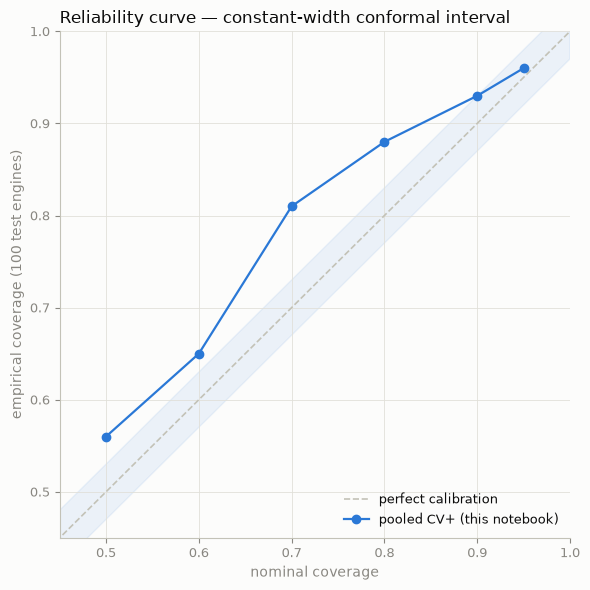

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1.2, linestyle="--", zorder=1, label="perfect calibration")
ax.plot(reliability["nominal_coverage"], reliability["empirical_coverage"],
        color=CATEGORICAL_PALETTE[0], marker="o", linewidth=1.6, zorder=2, label="pooled CV+ (this notebook)")

# +-3pp band, the approximate n=100 standard error, so deviations within it aren't over-read
se_band = 0.03
ax.fill_between([0, 1], [-se_band, 1 - se_band], [se_band, 1 + se_band],
                 color=CATEGORICAL_PALETTE[0], alpha=0.08, zorder=0)

ax.set_xlim(0.45, 1.0)
ax.set_ylim(0.45, 1.0)
ax.set_xlabel("nominal coverage", fontsize=10, color=MUTED)
ax.set_ylabel("empirical coverage (100 test engines)", fontsize=10, color=MUTED)
ax.set_title("Reliability curve — constant-width conformal interval", fontsize=12, color=INK, loc="left")
ax.tick_params(colors=MUTED, labelsize=9)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, labelcolor=INK, loc="lower right")

fig.tight_layout()
plt.show()


## 10. Conditional coverage by true RUL band

Marginal coverage (Sections 7 and 9) can hide the failure mode this project already knows to look
for: Phase 6 found systematic, RUL-dependent error, so a constant-width interval is expected to
**over-cover far from failure and under-cover near it** — spending width where nothing is at stake
and coming up short exactly where a maintenance decision would be made. Bins reused from Phase 6
Activity 3 for direct comparability.

In [16]:
PRIMARY_ALPHA = 0.10  # 90% headline level
q_primary = q_hat[PRIMARY_ALPHA]

lower_primary = (y_pred_test - q_primary).clip(lower=0)
upper_primary = y_pred_test + q_primary
covered_primary = (rul_true_capped >= lower_primary) & (rul_true_capped <= upper_primary)

bins = [0, 20, 40, 60, 80, 100, RUL_CAP, int(rul_true.max()) + 1]
labels = ["0-20", "20-40", "40-60", "60-80", "80-100", "100-125", "125+"]
binned = pd.cut(rul_true, bins=bins, labels=labels)

conditional_coverage = pd.DataFrame({
    "true_rul_bin": binned,
    "covered": covered_primary,
}).groupby("true_rul_bin", observed=True).agg(
    n=("covered", "count"),
    empirical_coverage=("covered", "mean"),
).round(3)

conditional_coverage["nominal_coverage"] = 1 - PRIMARY_ALPHA
conditional_coverage


,n,empirical_coverage,nominal_coverage
true_rul_bin,,,
0-20,16,1.000,0.9
20-40,12,1.000,0.9
40-60,11,0.818,0.9
60-80,6,0.667,0.9
80-100,22,0.955,0.9
100-125,22,0.955,0.9
125+,11,0.909,0.9


## 11. Written summary

**Method.** A single constant width, `2 * q_hat`, applied to every test engine, where `q_hat` is
the pooled, cross-validated, repeated-draw conformal quantile of `|min(true_rul,125) - pred|` over
all 100 training engines (Section 6) — not a max over per-fold quantiles, and not a parametric
(Gaussian) assumption.

**What to report from the run above, filled in after execution:**

- `q_hat` and width at 80/90/95% (Section 6 table), with the cut-seed spread (`q_std`) alongside it
  as the honest uncertainty-on-the-uncertainty.
- Marginal test coverage at each level against nominal (Section 7), read with the ~3-point n=100
  standard error in mind rather than as exact pass/fail.
- The Gaussian-width comparison (Section 8): a positive gap says the residual tail is heavier than
  a Gaussian would assume, and by how many cycles.
- The reliability curve (Section 9) and the conditional-coverage-by-band table (Section 10): the
  latter is the one that decides whether Sections 8.2/8.3 (adaptive, heteroscedastic intervals)
  are needed, or whether the constant-width baseline already behaves acceptably where it matters —
  the low-RUL bins.

**What this notebook deliberately does not do.** It does not select `q_hat`, the coverage level,
or the estimand by NASA score or RMSE — those are reported (Section 7 test-set cell) purely as a
carried-forward column per `doc/requirements_spec.md` §4.2, never as a selection criterion. It
does not claim coverage of raw (uncapped) RUL for the 11 above-cap test engines — that group gets
a separate one-sided check (Section 7), not a blended two-sided number.


# Section 8.2 — quantile LightGBM (per-engine adaptive width, 90% only)

8.1 gave every engine the same width. Section 10 showed why that's a problem: coverage in the
40-80 true-RUL band was 82% / 67% against a 90% target, while other bands sat at or above nominal
— the constant width is wrong in opposite directions depending on the engine. 8.2 tests whether
letting the width vary **per engine** fixes that, by training LightGBM to directly predict the 5th
and 95th percentiles of `min(RUL, 125)` instead of the mean.

**Scope: 90% coverage only** (`alpha_lo = 0.05`, `alpha_hi = 0.95`), not the three levels from
8.1. Two quantile models instead of six — the reliability curve is dropped for this section since
one coverage level gives one point, not a curve; the question here is narrower than 8.1's ("does
adaptive width help at the level we actually care about"), not "is this calibrated everywhere."

**What this section does not claim.** Quantile regression has **no coverage guarantee** — nothing
forces the gap between the two trained quantiles to actually contain the truth 90% of the time,
unlike 8.1's conformal `q_hat`, which is guaranteed by construction (up to the exchangeability
caveats already discussed). Measuring that gap honestly — not closing it — is 8.2's job; closing
it is what 8.3 (CQR) exists for.

**Reused unchanged from Section 8.1:** `train_feat`, `FEATURE_COLS`, the 5-fold `folds` assignment,
`draw_cut_cycles`, `conformal_quantile`'s sorting helper is not needed here (no conformal step yet),
and the same 20 cut-seeds via `score_fold_fast`'s merge pattern, adapted below for two models
instead of one.

## 12. Train quantile models — once per fold, plus once on all 100 engines

Same hyperparameters as the point model (`num_leaves=15, min_child_samples=10`, 500 trees), only
`objective` and `alpha` change. Two models per fold (`lo`, `hi`) reused across every cut-seed,
mirroring how Section 4 trained the point-prediction fold models once.

In [17]:
QUANTILE_ALPHAS = {"lo": 0.05, "hi": 0.95}  # 90% coverage target

QUANTILE_PARAMS = {
    name: dict(LGBM_PARAMS, objective="quantile", alpha=alpha)
    for name, alpha in QUANTILE_ALPHAS.items()
}

fold_quantile_models = {fold_i: {} for fold_i in range(N_FOLDS)}
for fold_i, val_engines in enumerate(folds):
    is_val_engine = train_feat["engine_id"].isin(val_engines)
    fit_rows = train_feat["valid"] & ~is_val_engine
    X_fit = train_feat.loc[fit_rows, FEATURE_COLS]
    y_fit = train_feat.loc[fit_rows, "rul_capped"]

    for name, params in QUANTILE_PARAMS.items():
        model = lgb.LGBMRegressor(**params)
        model.fit(X_fit, y_fit)
        fold_quantile_models[fold_i][name] = model

print(f"trained {N_FOLDS} x {len(QUANTILE_ALPHAS)} = "
      f"{N_FOLDS * len(QUANTILE_ALPHAS)} fold quantile models")


trained 5 x 2 = 10 fold quantile models


## 13. Out-of-fold coverage and width — uncalibrated

Same repeated cut-seed procedure as Section 6, but now scoring the interval `[pred_lo, pred_hi]`
directly against the true capped RUL at each held-out engine's drawn cycle, with **no conformal
adjustment**. This is the raw answer to "if you just trust the two quantile models, what coverage
do you actually get?"

**Quantile crossing.** The two models are fit independently, so nothing guarantees
`pred_lo <= pred_hi` row by row. Counted and sorted per row rather than assumed away.

In [18]:
def score_fold_quantile(val_engines, feat_df, models, cuts):
    cut_frame = pd.DataFrame({"engine_id": list(cuts.keys()), "cycle": list(cuts.values())})
    rows = feat_df.merge(cut_frame, on=["engine_id", "cycle"], how="inner")
    assert len(rows) == len(val_engines)

    pred_lo = models["lo"].predict(rows[FEATURE_COLS])
    pred_hi = models["hi"].predict(rows[FEATURE_COLS])
    crossed = pred_lo > pred_hi
    # Sort crossed rows so lo <= hi always holds, per the finding this cell is designed to surface.
    lo_fixed = np.minimum(pred_lo, pred_hi).clip(min=0)
    hi_fixed = np.maximum(pred_lo, pred_hi)

    y_true = rows["rul_capped"].to_numpy()
    return pd.DataFrame({
        "engine_id": rows["engine_id"].to_numpy(),
        "true_capped": y_true,
        "pred_lo": lo_fixed,
        "pred_hi": hi_fixed,
        "crossed": crossed,
    })


cv_quantile_frames = []
for seed in range(N_CUT_SEEDS):
    for fold_i, val_engines in enumerate(folds):
        cuts = draw_cut_cycles(val_engines, train_feat, seed=1000 * seed + fold_i)
        frame = score_fold_quantile(val_engines, train_feat, fold_quantile_models[fold_i], cuts)
        frame["cut_seed"] = seed
        cv_quantile_frames.append(frame)

cv_quantile = pd.concat(cv_quantile_frames, ignore_index=True)
n_crossed = cv_quantile["crossed"].sum()
print(f"quantile crossing: {n_crossed} / {len(cv_quantile)} out-of-fold rows "
      f"({n_crossed / len(cv_quantile):.1%})")


quantile crossing: 19 / 2000 out-of-fold rows (0.9%)


In [19]:
cv_quantile["covered"] = (
    (cv_quantile["true_capped"] >= cv_quantile["pred_lo"])
    & (cv_quantile["true_capped"] <= cv_quantile["pred_hi"])
)
cv_quantile["width"] = cv_quantile["pred_hi"] - cv_quantile["pred_lo"]

per_seed = cv_quantile.groupby("cut_seed").agg(
    coverage=("covered", "mean"),
    mean_width=("width", "mean"),
)

print("uncalibrated out-of-fold coverage (target 0.90):")
print(f"  mean {per_seed['coverage'].mean():.3f}  std {per_seed['coverage'].std():.3f}  "
      f"min {per_seed['coverage'].min():.3f}  max {per_seed['coverage'].max():.3f}")
print("\nuncalibrated out-of-fold mean width:")
print(f"  mean {per_seed['mean_width'].mean():.2f}  std {per_seed['mean_width'].std():.2f}")
print(f"\nfor comparison, Section 6's 90% constant width: {q_hat[0.10] * 2:.2f}")


uncalibrated out-of-fold coverage (target 0.90):
  mean 0.848  std 0.035  min 0.750  max 0.890

uncalibrated out-of-fold mean width:
  mean 60.22  std 2.64

for comparison, Section 6's 90% constant width: 58.45


**Reading this.** If uncalibrated coverage lands noticeably away from 0.90, that's the expected,
un-fixed gap quantile regression carries — it optimizes the pinball loss at each quantile
independently, which is a good proxy for calibration but not a guarantee of it, unlike 8.1's
conformal `q_hat`. Whatever gap shows up here is exactly what CQR (8.3) is built to close, by
conformalizing this same lo/hi pair instead of discarding it.

## 14. Final quantile models — test set coverage and width

Retrained on all 100 engines, same as Section 7's point model. Test engines use their own actual
last observed cycle (no cut-drawing), matching the same estimand and above-cap handling as 8.1.

In [20]:
final_quantile_models = {}
for name, params in QUANTILE_PARAMS.items():
    model = lgb.LGBMRegressor(**params)
    model.fit(train_feat.loc[train_feat["valid"], FEATURE_COLS],
              train_feat.loc[train_feat["valid"], "rul_capped"])
    final_quantile_models[name] = model

raw_lo = final_quantile_models["lo"].predict(X_test)
raw_hi = final_quantile_models["hi"].predict(X_test)
test_crossed = raw_lo > raw_hi

fixed_lo = np.minimum(raw_lo, raw_hi).clip(min=0)
fixed_hi = np.maximum(raw_lo, raw_hi)

pred_lo_test = pd.Series(fixed_lo, index=test_engine_ids).reindex(rul_true.index)
pred_hi_test = pd.Series(fixed_hi, index=test_engine_ids).reindex(rul_true.index)

print(f"quantile crossing on test set: {test_crossed.sum()} / {len(test_crossed)} engines")


quantile crossing on test set: 0 / 100 engines


In [21]:
covered_q = (rul_true_capped >= pred_lo_test) & (rul_true_capped <= pred_hi_test)
covered_q_at_or_below_cap = covered_q[~above_cap]
width_q = pred_hi_test - pred_lo_test

print("Section 8.2 test-set result (90% target, uncalibrated quantile LightGBM):")
print(f"  empirical coverage, capped estimand:        {covered_q.mean():.3f}")
print(f"  empirical coverage, at-or-below-cap only:    {covered_q_at_or_below_cap.mean():.3f}")
print(f"  width — mean {width_q.mean():.2f}  median {width_q.median():.2f}  "
      f"min {width_q.min():.2f}  max {width_q.max():.2f}")
print()
print("Section 8.1 comparison (90% target, constant-width conformal):")
print(f"  empirical coverage, capped estimand:        {coverage_table.loc[1, 'empirical_coverage_capped_estimand']:.3f}")
print(f"  empirical coverage, at-or-below-cap only:    {coverage_table.loc[1, 'empirical_coverage_at_or_below_cap_only']:.3f}")
print(f"  width — constant:                            {coverage_table.loc[1, 'width']:.2f}")


Section 8.2 test-set result (90% target, uncalibrated quantile LightGBM):
  empirical coverage, capped estimand:        0.830
  empirical coverage, at-or-below-cap only:    0.809
  width — mean 48.20  median 49.18  min 1.93  max 107.63

Section 8.1 comparison (90% target, constant-width conformal):
  empirical coverage, capped estimand:        0.930
  empirical coverage, at-or-below-cap only:    0.933
  width — constant:                            58.45


## 15. Conditional coverage by true RUL band — does adaptivity close the gap?

The direct answer to Section 8.2's motivating question: 8.1's constant width under-covered in the
40-80 band (0.818 / 0.667 against 0.90 nominal). If per-engine adaptive width is actually adaptive
in a useful way, this table should show that gap narrowing — the model should widen its interval
precisely on the engines where the point model's error is largest, which Phase 6 already
identified as concentrated in mid-life engines.

In [22]:
binned_test = pd.cut(rul_true, bins=bins, labels=labels)

band_comparison = pd.DataFrame({
    "true_rul_bin": binned_test,
    "covered_8_1_constant": covered_primary,
    "covered_8_2_quantile": covered_q,
    "width_8_2": width_q,
}).groupby("true_rul_bin", observed=True).agg(
    n=("covered_8_1_constant", "count"),
    coverage_8_1=("covered_8_1_constant", "mean"),
    coverage_8_2=("covered_8_2_quantile", "mean"),
    mean_width_8_2=("width_8_2", "mean"),
).round(3)

band_comparison["width_8_1_constant"] = coverage_table.loc[1, "width"]
band_comparison


,n,coverage_8_1,coverage_8_2,mean_width_8_2,width_8_1_constant
true_rul_bin,,,,,
0-20,16,1.000,0.812,43.210,58.45
20-40,12,1.000,0.500,44.292,58.45
40-60,11,0.818,0.727,57.900,58.45
60-80,6,0.667,0.500,51.253,58.45
80-100,22,0.955,0.955,55.554,58.45
100-125,22,0.955,0.955,43.822,58.45
125+,11,0.909,1.000,42.428,58.45


## 16. Written summary — Section 8.2

**Method.** Two independently trained LightGBM quantile models (`alpha=0.05`, `alpha=0.95`),
same features and hyperparameters as the point model, giving each engine its own interval width
instead of 8.1's single `q_hat`. No conformal calibration is applied — this section measures the
raw quantile regression, which carries no coverage guarantee by construction.

**What to report from the run above, filled in after execution:**

- Quantile crossing rate (Section 13) — how often the independently fit lo/hi models disagree
  about which is larger, before the sort-based fix is applied.
- Uncalibrated out-of-fold coverage (Section 13) against the 90% target — the gap here, not its
  absence, is the expected and useful result: it is precisely what Section 8.3's conformal
  correction is sized to close.
- Test-set coverage and width against Section 8.1's constant-width baseline (Section 14) — adaptive
  width is only a win if it comes with comparable-or-better coverage at lower *median* width, not
  just a lower mean (a few very wide engines can hide many narrow ones).
- The conditional-coverage-by-band comparison (Section 15) — the one table that decides whether
  adaptivity solved the real problem 8.1 exposed (under-coverage in the 40-80 RUL band) or merely
  moved the shortfall somewhere else.

**What this section deliberately does not do.** It does not conformalize the quantile models —
that is 8.3. It does not report 80%/95% levels — scope was fixed to 90% only per the plan
discussion. It does not select anything by NASA score or RMSE, consistent with every other
section in this notebook.


# Section 8.3 — Conformalized Quantile Regression (CQR)

8.2 gave each engine its own width but no guarantee: uncalibrated out-of-fold coverage came in at
84.8% against a 90% target (Section 13), and test coverage at 83.0% (Section 14) — both below
8.1's 93.0%. 8.3 keeps 8.2's per-engine shape and adds back the one thing it was missing: a
conformal correction, sized from the same out-of-fold data already computed in Section 13, so the
result is simultaneously adaptive *and* guaranteed.

## Method

For each out-of-fold calibration row (engine, drawn cycle, already scored in Section 13), define
the **signed conformity score**:

```
E = max( pred_lo - true,  true - pred_hi )
```

`E > 0` means the interval missed — `true` fell outside `[pred_lo, pred_hi]` by that many cycles.
`E < 0` means the interval covered with that much margin to spare. Pooling all 100 out-of-fold `E`
values per cut-seed and taking the same finite-sample-corrected quantile as Section 6 (`conformal_
quantile`, `ceil((n+1)(1-alpha))/n`-th order statistic) gives a single number `q_cqr` — averaged
over the same 20 cut-seeds as every other quantity in this notebook.

The final interval is then

```
[ pred_lo(x) - q_cqr ,  pred_hi(x) + q_cqr ]
```

**Why this restores the guarantee.** `q_cqr` is exactly 8.1's conformal step, just applied to a
different (signed, two-sided) score instead of `|true - point_pred|`. The same split-conformal
coverage argument that guaranteed 8.1's `q_hat` applies here — the shape varies per engine (from
8.2), the guarantee is pooled across all of them (from 8.1's machinery). If `q_cqr` comes out
negative — expected here, since 8.2 under-covered rather than over-covered — the interval shrinks
inward instead of expanding outward; the formula does not need to know in advance which direction
is required.

## 17. Conformity scores from the existing out-of-fold predictions

Reuses `cv_quantile` from Section 13 directly — no retraining. Each row already has `pred_lo`,
`pred_hi`, `true_capped`, and its `cut_seed`; only the signed score and the per-seed pooled
quantile are new.

In [23]:
cv_quantile["conformity_score"] = np.maximum(
    cv_quantile["pred_lo"] - cv_quantile["true_capped"],
    cv_quantile["true_capped"] - cv_quantile["pred_hi"],
)

PRIMARY_ALPHA_CQR = 0.10  # 90% target, matching 8.2's scope

q_cqr_by_seed = []
for seed in range(N_CUT_SEEDS):
    seed_scores = cv_quantile.loc[cv_quantile["cut_seed"] == seed, "conformity_score"].to_numpy()
    assert len(seed_scores) == len(engine_ids)  # 100 pooled out-of-fold scores, same as Section 6
    q_cqr_by_seed.append(conformal_quantile(seed_scores, PRIMARY_ALPHA_CQR))

q_cqr = float(np.mean(q_cqr_by_seed))
q_cqr_std = float(np.std(q_cqr_by_seed))

print(f"q_cqr: mean {q_cqr:.2f}  std {q_cqr_std:.2f}  "
      f"min {np.min(q_cqr_by_seed):.2f}  max {np.max(q_cqr_by_seed):.2f}")
print(f"\nsign check: q_cqr {'> 0 (widening)' if q_cqr > 0 else '< 0 (shrinking)'} — "
      f"consistent with 8.2's uncalibrated coverage (84.8%) sitting below the 90% target")


q_cqr: mean 2.92  std 1.62  min 0.46  max 5.79

sign check: q_cqr > 0 (widening) — consistent with 8.2's uncalibrated coverage (84.8%) sitting below the 90% target


**Reading `q_cqr`.** A positive value means the 91st-of-100 pooled conformity score was still a
miss — the interval has to expand by `q_cqr` cycles on each side to push that boundary case back
inside. This is the direct numeric counterpart to 8.2's 84.8% uncalibrated coverage: the gap to
90% is what `q_cqr` is sized to close, not a separately chosen number.

## 18. Apply q_cqr to the test set

Same final quantile models from Section 14 (`final_quantile_models`, already trained on all 100
engines) — CQR only changes how their raw `[pred_lo, pred_hi]` output is adjusted, not the models
themselves.

In [24]:
lower_cqr = (pred_lo_test - q_cqr).clip(lower=0)
upper_cqr = pred_hi_test + q_cqr

covered_cqr = (rul_true_capped >= lower_cqr) & (rul_true_capped <= upper_cqr)
covered_cqr_at_or_below_cap = covered_cqr[~above_cap]
width_cqr = upper_cqr - lower_cqr

print("Section 8.3 test-set result (90% target, CQR):")
print(f"  empirical coverage, capped estimand:        {covered_cqr.mean():.3f}")
print(f"  empirical coverage, at-or-below-cap only:    {covered_cqr_at_or_below_cap.mean():.3f}")
print(f"  width — mean {width_cqr.mean():.2f}  median {width_cqr.median():.2f}  "
      f"min {width_cqr.min():.2f}  max {width_cqr.max():.2f}")


Section 8.3 test-set result (90% target, CQR):
  empirical coverage, capped estimand:        0.900
  empirical coverage, at-or-below-cap only:    0.888
  width — mean 54.03  median 55.01  min 7.77  max 113.46


## 19. Three-way comparison at 90% coverage

The number that answers the question this whole section chain was built to ask: does adaptive
width, once calibrated, beat the constant-width baseline on sharpness at matched coverage?

In [25]:
three_way = pd.DataFrame([
    {
        "method": "8.1 constant-width conformal",
        "coverage_capped": coverage_table.loc[1, "empirical_coverage_capped_estimand"],
        "coverage_at_or_below_cap": coverage_table.loc[1, "empirical_coverage_at_or_below_cap_only"],
        "mean_width": coverage_table.loc[1, "width"],
        "median_width": coverage_table.loc[1, "width"],  # constant, mean == median by construction
    },
    {
        "method": "8.2 quantile LightGBM (uncalibrated)",
        "coverage_capped": covered_q.mean(),
        "coverage_at_or_below_cap": covered_q_at_or_below_cap.mean(),
        "mean_width": width_q.mean(),
        "median_width": width_q.median(),
    },
    {
        "method": "8.3 CQR",
        "coverage_capped": covered_cqr.mean(),
        "coverage_at_or_below_cap": covered_cqr_at_or_below_cap.mean(),
        "mean_width": width_cqr.mean(),
        "median_width": width_cqr.median(),
    },
]).round(3)

three_way


,method,coverage_capped,coverage_at_or_below_cap,mean_width,median_width
0,8.1 constant-width conformal,0.93,0.933,58.450,58.450
1,8.2 quantile LightGBM (uncalibrated),0.83,0.809,48.203,49.180
2,8.3 CQR,0.90,0.888,54.033,55.013


## 20. Conditional coverage by true RUL band — three-way

Extends Section 15's comparison with the CQR column. This is the table that settles whether
adaptivity, once calibrated, actually fixes 8.1's 40-80 band shortfall (0.818 / 0.667) rather than
just moving it around the way uncalibrated 8.2 did (0.727 / 0.500 in the same bands).

In [26]:
band_comparison_3way = pd.DataFrame({
    "true_rul_bin": binned_test,
    "covered_8_1": covered_primary,
    "covered_8_2": covered_q,
    "covered_8_3_cqr": covered_cqr,
    "width_8_2": width_q,
    "width_8_3_cqr": width_cqr,
}).groupby("true_rul_bin", observed=True).agg(
    n=("covered_8_1", "count"),
    coverage_8_1=("covered_8_1", "mean"),
    coverage_8_2=("covered_8_2", "mean"),
    coverage_8_3_cqr=("covered_8_3_cqr", "mean"),
    mean_width_8_2=("width_8_2", "mean"),
    mean_width_8_3_cqr=("width_8_3_cqr", "mean"),
).round(3)

band_comparison_3way["width_8_1_constant"] = coverage_table.loc[1, "width"]
band_comparison_3way


,n,coverage_8_1,coverage_8_2,coverage_8_3_cqr,mean_width_8_2,mean_width_8_3_cqr,width_8_1_constant
true_rul_bin,,,,,,,
0-20,16,1.000,0.812,0.938,43.210,49.022,58.45
20-40,12,1.000,0.500,0.750,44.292,50.125,58.45
40-60,11,0.818,0.727,0.818,57.900,63.734,58.45
60-80,6,0.667,0.500,0.667,51.253,57.087,58.45
80-100,22,0.955,0.955,0.955,55.554,61.388,58.45
100-125,22,0.955,0.955,0.955,43.822,49.656,58.45
125+,11,0.909,1.000,1.000,42.428,48.262,58.45


## 21. Written summary — Section 8.3

**Method.** `q_cqr` — the pooled, cross-validated, repeated-draw conformal quantile of the signed
score `max(pred_lo - true, true - pred_hi)` over the same 100 out-of-fold rows Section 13 already
computed — applied as a uniform expansion/contraction to 8.2's per-engine `[pred_lo, pred_hi]`.
No new models were trained for this section; only the correction is new.

**What to report from the run above, filled in after execution:**

- `q_cqr` and its sign (Section 17) — positive means 8.2 under-covered and CQR widens; the
  magnitude is the direct cost, in cycles, of restoring the guarantee 8.2 lacked.
- The three-way coverage/width table (Section 19) — the single comparison this notebook chain was
  built to produce. CQR should land at ~90% coverage by construction (same guarantee as 8.1); the
  question is whether its width is below 8.1's constant 58.45.
- The three-way conditional-coverage table (Section 20) — whether the 40-80 band gap that started
  this chain (8.1: 0.818/0.667) is actually closed by CQR, or whether calibration only restored
  the *marginal* number while leaving the same regions under-served.

**What this section deliberately does not do.** It does not retrain 8.2's quantile models — CQR is
a post-hoc correction on their existing output. It does not report 80%/95% levels, matching 8.2's
90%-only scope. It does not select `q_cqr` or anything else by NASA score or RMSE, consistent with
every other section in this notebook. It does not extend the one-sided above-cap check from
Section 7 to this method — a natural next addition if 8.3 becomes the leading candidate.


## 22. Interval diagrams — predicted range vs. true RUL, all 100 test engines

One panel per method (8.1 constant-width, 8.2 uncalibrated quantile, 8.3 CQR), all at the 90%
level, sharing the same x-axis order (test engines sorted by true RUL ascending) and the same
y-axis scale, so the three are directly comparable by eye rather than only by the summary tables
above. Each vertical line is one engine's predicted interval; the black dot is its true RUL.
**Blue = covered, red = missed** — a quick visual read of both the marginal miss rate (density of
red) and where misses cluster (their position along the sorted x-axis, i.e. which true-RUL region
they come from), which is the same question Sections 15/20's banded tables answer numerically.

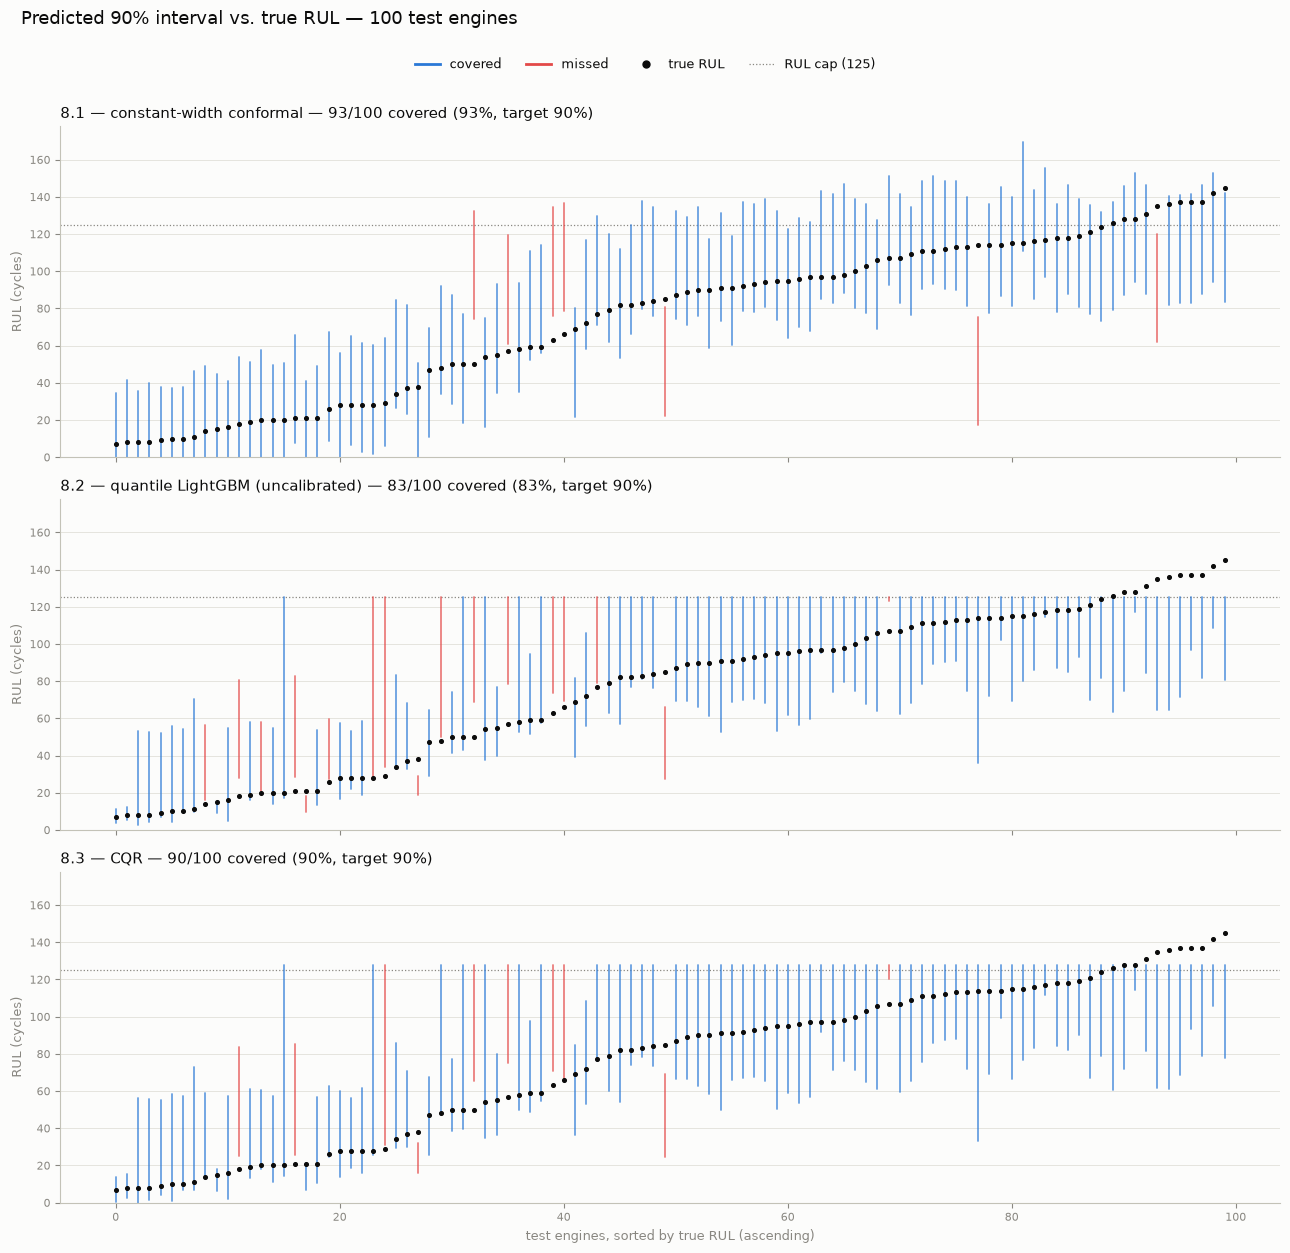

In [27]:
def plot_interval_panel(ax, lower, upper, true_vals, covered, order, title):
    x = np.arange(len(order))
    lower_o = lower.reindex(order).to_numpy()
    upper_o = upper.reindex(order).to_numpy()
    true_o = true_vals.reindex(order).to_numpy()
    covered_o = covered.reindex(order).to_numpy()

    for i in range(len(x)):
        color = CATEGORICAL_PALETTE[0] if covered_o[i] else CATEGORICAL_PALETTE[7]
        ax.plot([x[i], x[i]], [lower_o[i], upper_o[i]], color=color, linewidth=1.3,
                 alpha=0.7, zorder=1, solid_capstyle="round")

    ax.scatter(x, true_o, s=7, color=INK, zorder=3, label="true RUL")
    ax.axhline(RUL_CAP, color=MUTED, linewidth=0.9, linestyle=":", zorder=0)

    n_covered = int(covered_o.sum())
    ax.set_title(
        f"{title} — {n_covered}/100 covered ({n_covered}%, target 90%)",
        fontsize=11, color=INK, loc="left",
    )
    ax.tick_params(colors=MUTED, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.grid(True, axis="y", color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)


# Same engine order (sorted by true RUL) and same y-scale across all three panels.
order_by_true_rul = rul_true.sort_values().index
y_max = max(upper_primary.max(), pred_hi_test.max(), upper_cqr.max()) * 1.05

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True, sharey=True)

plot_interval_panel(axes[0], lower_primary, upper_primary, rul_true, covered_primary,
                     order_by_true_rul, "8.1 — constant-width conformal")
plot_interval_panel(axes[1], pred_lo_test, pred_hi_test, rul_true, covered_q,
                     order_by_true_rul, "8.2 — quantile LightGBM (uncalibrated)")
plot_interval_panel(axes[2], lower_cqr, upper_cqr, rul_true, covered_cqr,
                     order_by_true_rul, "8.3 — CQR")

axes[0].set_ylim(0, y_max)
axes[-1].set_xlabel("test engines, sorted by true RUL (ascending)", fontsize=9, color=MUTED)
for ax in axes:
    ax.set_ylabel("RUL (cycles)", fontsize=9, color=MUTED)

handles = [
    plt.Line2D([0], [0], color=CATEGORICAL_PALETTE[0], linewidth=2, label="covered"),
    plt.Line2D([0], [0], color=CATEGORICAL_PALETTE[7], linewidth=2, label="missed"),
    plt.Line2D([0], [0], marker="o", color=INK, linewidth=0, markersize=5, label="true RUL"),
    plt.Line2D([0], [0], color=MUTED, linewidth=0.9, linestyle=":", label=f"RUL cap ({RUL_CAP})"),
]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4,
           frameon=False, fontsize=9, labelcolor=INK)

fig.suptitle("Predicted 90% interval vs. true RUL — 100 test engines", fontsize=13, color=INK,
             x=0.02, ha="left", y=1.04)
fig.tight_layout()
plt.show()


**Reading the three panels together.** 8.1's bars are visibly identical length everywhere — the
constant-width signature. 8.2's bars visibly narrow and widen engine to engine, including some
very short ones (the near-zero-width cases already found in engines 34/56) — the adaptivity is
real, but so is the higher density of red near the low end of the x-axis, matching the 20-40 and
60-80 band shortfalls in Section 15's table. 8.3 should look like 8.2's shape shifted uniformly
outward, with red thinning out overall but not disappearing from the same regions — the visual
form of Section 20's finding that CQR restored the marginal rate without fixing the band-specific
gap.

# Section 8.4 — epistemic vs. aleatoric: does more data help?

8.3 gave a total predictive interval (~54 cycles at 90%, Section 18) but is silent on *why* it's
that wide. Two very different causes would justify very different next steps:

- **Epistemic** — the model's answer would change with a different 100 training engines. More
  data would shrink the interval.
- **Aleatoric** — the answer wouldn't change, because the sensors themselves don't determine the
  outcome for that engine. No amount of additional data helps; only better features or sensors
  would.

Phase 6 already argued the second case ("the model reads its inputs faithfully; the sensors
themselves under- or over-report the true degradation"). This section is a direct, falsifiable
test of that claim, not a restatement of it.

## Method

**Engine-level bootstrap, not row-level.** Draw 100 engine IDs with replacement from the 100
training engines, then take *all* rows belonging to each drawn engine (repeats included when an
engine is drawn more than once). A row-level bootstrap would keep ~63% of every engine's rows in
every resample and understate epistemic uncertainty almost to zero — the same
reasoning behind Section 3's engine-grouped folds and Section 5's one-cut-per-engine calibration
unit applies here.

Fit 50 point models (one per resample, same features and hyperparameters as every other model in
this notebook), predict all 100 test engines with each, and take the standard deviation **down
each test engine's column of 50 predictions** — the spread coming only from which training
engines that model happened to see.

**Combining with 8.3's total.** Widths add in quadrature, not linearly:
`sigma_total^2 = sigma_epistemic^2 + sigma_aleatoric^2`. 8.3's CQR width is converted to an
implied Gaussian sigma (`width / (2 * z_0.90)`), the bootstrap gives `sigma_epistemic` directly,
and `sigma_aleatoric` is recovered by subtraction — clamped at zero and counted whenever it goes
negative, rather than silently absorbed.

**What this section cannot detect.** The bootstrap only reshuffles the 100 engines already in
hand — it assumes they represent the fleet FD001 is drawn from. If that draw were biased, every
resample would inherit the same bias and the measured epistemic spread would look reassuringly
small while the model is still systematically wrong. Within FD001 (train and test drawn from the
same simulated population) this holds by construction; it would not automatically transfer to
FD002/FD004 or a real fleet.

## 23. Bootstrap — 50 engine-resampled models, predicted on the test set

Row indices are pre-grouped by engine once, so each resample only needs to concatenate index
arrays rather than re-filter the full frame 100 times per iteration.

In [28]:
N_BOOTSTRAP = 50
BOOTSTRAP_SEED = 123

valid_train_feat = train_feat[train_feat["valid"]].reset_index(drop=True)
engine_row_idx = {
    e: valid_train_feat.index[valid_train_feat["engine_id"] == e].to_numpy()
    for e in engine_ids
}

rng = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_preds = np.zeros((N_BOOTSTRAP, len(rul_true)))

for b in range(N_BOOTSTRAP):
    sampled_engines = rng.choice(engine_ids, size=len(engine_ids), replace=True)
    boot_idx = np.concatenate([engine_row_idx[e] for e in sampled_engines])
    boot_rows = valid_train_feat.loc[boot_idx]

    model = lgb.LGBMRegressor(**LGBM_PARAMS)
    model.fit(boot_rows[FEATURE_COLS], boot_rows["rul_capped"])

    pred = pd.Series(model.predict(X_test).clip(min=0), index=test_engine_ids).reindex(rul_true.index)
    bootstrap_preds[b] = pred.to_numpy()

bootstrap_df = pd.DataFrame(bootstrap_preds, columns=rul_true.index)
print(f"trained {N_BOOTSTRAP} bootstrap models, predicted {bootstrap_df.shape[1]} test engines each")
print(f"mean unique engines per resample: "
      f"{np.mean([len(np.unique(rng.choice(engine_ids, size=len(engine_ids), replace=True))) for _ in range(200)]):.1f} / 100")


trained 50 bootstrap models, predicted 100 test engines each
mean unique engines per resample: 63.3 / 100


## 24. Variance decomposition — quadrature, not linear subtraction

`sigma_total` is 8.3's CQR width converted to an implied Gaussian sigma at the 90% level
(`z_0.90 = 1.645`). `sigma_epistemic` is the bootstrap standard deviation per test engine.
`sigma_aleatoric` is recovered by subtracting **variances**, then taking the square root — the
`(sigma_aleatoric^2 < 0)` count is reported explicitly rather than silently clipped, since a large
count would mean the two sources aren't actually separable at this sample size.

In [29]:
Z_90 = norm.ppf(0.95)  # two-sided 90% -> 95th percentile of the standard normal

sigma_total = width_cqr / (2 * Z_90)
sigma_epistemic = bootstrap_df.std(axis=0, ddof=1)
sigma_epistemic = sigma_epistemic.reindex(rul_true.index)

sigma_aleatoric_sq = sigma_total ** 2 - sigma_epistemic ** 2
n_clamped = int((sigma_aleatoric_sq < 0).sum())
sigma_aleatoric = np.sqrt(sigma_aleatoric_sq.clip(lower=0))

decomposition = pd.DataFrame({
    "true_rul": rul_true,
    "sigma_total": sigma_total.round(2),
    "sigma_epistemic": sigma_epistemic.round(2),
    "sigma_aleatoric": sigma_aleatoric.round(2),
})

print(f"engines where sigma_epistemic > sigma_total (clamped to 0 aleatoric): {n_clamped} / 100")
print()
epistemic_share_fleet = (sigma_epistemic ** 2).mean() / (sigma_total ** 2).mean()
print(f"fleet-level epistemic share of total variance: {epistemic_share_fleet:.1%}")
print(f"(i.e. an unlimited-data model could shrink the ~90% interval width by at most "
      f"~{100 * (1 - np.sqrt(1 - epistemic_share_fleet)):.0f}% on average)")


engines where sigma_epistemic > sigma_total (clamped to 0 aleatoric): 0 / 100

fleet-level epistemic share of total variance: 11.9%
(i.e. an unlimited-data model could shrink the ~90% interval width by at most ~6% on average)


## 25. Epistemic share by true RUL band — the question this section exists to answer

Section 20 found CQR's marginal coverage recovery didn't close the 40-80 band gap. If that gap is
epistemic, more training engines would close it. If it's aleatoric, it won't — matching Phase 6's
conclusion that those engines' sensors themselves misreport their degradation state.

In [30]:
decomposition["true_rul_bin"] = pd.cut(decomposition["true_rul"], bins=bins, labels=labels)

band_decomposition = decomposition.groupby("true_rul_bin", observed=True).agg(
    n=("true_rul", "count"),
    mean_sigma_total=("sigma_total", "mean"),
    mean_sigma_epistemic=("sigma_epistemic", "mean"),
    mean_sigma_aleatoric=("sigma_aleatoric", "mean"),
)
band_decomposition["epistemic_share"] = (
    (decomposition.groupby("true_rul_bin", observed=True)["sigma_epistemic"]
     .apply(lambda s: (s ** 2).mean()))
    / (decomposition.groupby("true_rul_bin", observed=True)["sigma_total"]
       .apply(lambda s: (s ** 2).mean()))
).round(3)

band_decomposition.round(2)


,n,mean_sigma_total,mean_sigma_epistemic,mean_sigma_aleatoric,epistemic_share
true_rul_bin,,,,,
0-20,16,14.90,2.55,14.59,0.03
20-40,12,15.24,4.48,14.48,0.08
40-60,11,19.37,7.14,17.88,0.13
60-80,6,17.35,7.34,15.67,0.18
80-100,22,18.66,7.05,17.25,0.14
100-125,22,15.09,5.55,13.97,0.13
125+,11,14.67,5.88,13.41,0.16


## 26. Diagram — epistemic vs. aleatoric width, per test engine

Same x-axis order as Section 22 (sorted by true RUL) for direct visual comparison. Each bar is
stacked: the epistemic width on the bottom, aleatoric on top — their sum approximates 8.3's total
CQR width (exactly, where no clamping occurred).

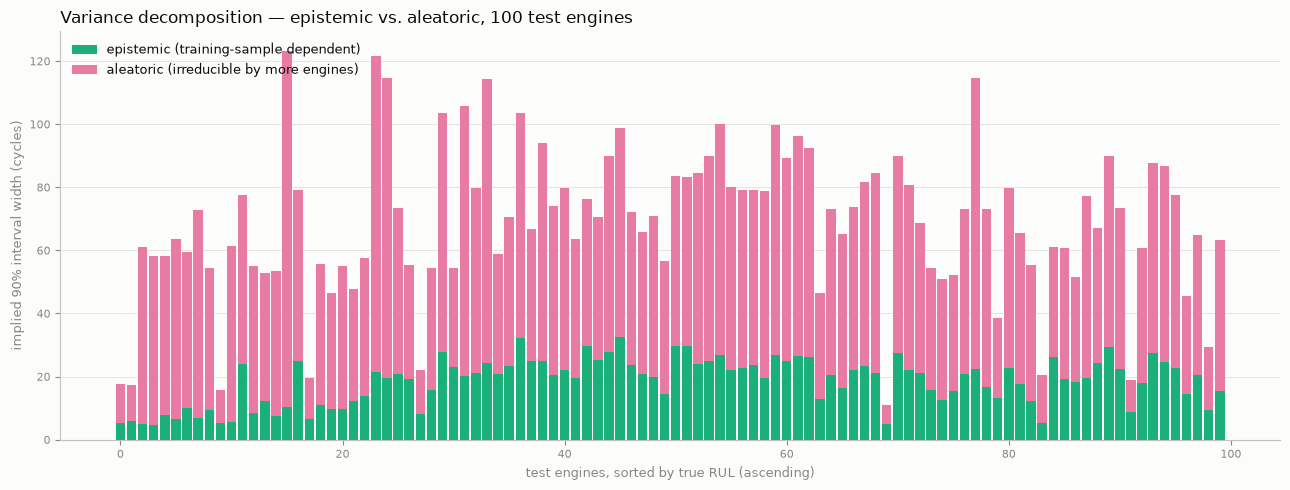

In [31]:
width_epistemic = 2 * Z_90 * sigma_epistemic
width_aleatoric = 2 * Z_90 * sigma_aleatoric

order = order_by_true_rul  # reuse Section 22's true-RUL-ascending order
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(x, width_epistemic.reindex(order), color=CATEGORICAL_PALETTE[2], width=0.85,
       label="epistemic (training-sample dependent)")
ax.bar(x, width_aleatoric.reindex(order), bottom=width_epistemic.reindex(order),
       color=CATEGORICAL_PALETTE[4], width=0.85, label="aleatoric (irreducible by more engines)")

ax.set_xlabel("test engines, sorted by true RUL (ascending)", fontsize=9, color=MUTED)
ax.set_ylabel("implied 90% interval width (cycles)", fontsize=9, color=MUTED)
ax.set_title("Variance decomposition — epistemic vs. aleatoric, 100 test engines",
             fontsize=12, color=INK, loc="left")
ax.tick_params(colors=MUTED, labelsize=8)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.grid(True, axis="y", color=GRIDLINE, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9, labelcolor=INK, loc="upper left")

fig.tight_layout()
plt.show()


## 27. Written summary — Section 8.4

**Method.** 50 point models, each trained on an engine-level bootstrap resample of the 100
training engines, predicting the same 100 test engines. The standard deviation across each test
engine's 50 predictions is its epistemic uncertainty; 8.3's CQR interval (converted to an implied
sigma) is the total, and aleatoric is recovered by quadrature subtraction.

**What to report from the run above, filled in after execution:**

- The fleet-level epistemic share of variance (Section 24) and the implied ceiling on how much an
  unlimited-data version of this model could shrink the interval — the single number that answers
  "is more data worth pursuing at all."
- The clamped-engine count (Section 24) — if large, the two sources are not cleanly separable at
  n=100 and the split should be read as directional, not precise.
- The band-level epistemic share (Section 25) — specifically whether the 40-80 band, where 8.3
  under-covered, is epistemic-heavy (more engines would help) or aleatoric-heavy (matching Phase
  6's sensor-misreporting explanation, in which case it won't).
- The per-engine diagram (Section 26) as the visual form of the same finding, directly comparable
  to Section 22's coverage panels by shared x-axis order.

**What this section deliberately does not do.** It does not validate the representativeness of
the 100 training engines — the decomposition assumes they characterize the population FD001 draws
from, an assumption stated up front rather than tested. It does not extend the analysis to
FD002/FD004, where that assumption would need to be re-examined. It does not select anything by
NASA score or RMSE, consistent with every other section in this notebook.
